In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, LeaveOneOut, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
import pickle
import os

In [2]:
#load dataset
df = pd.read_csv("../Data/processed/heart_disease_scaled.csv")
X = df.drop(columns=['heart_disease_present'])
y = df['heart_disease_present']

# Preprocess X to be numeric
X = pd.get_dummies(X)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
X.head()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,...,patient_id_yx0q6k,patient_id_z5g5p3,patient_id_z7xkou,patient_id_z8yl4y,patient_id_zaytyf,patient_id_zlyac8,patient_id_zzmfh7,thal_fixed_defect,thal_normal,thal_reversible_defect
0,0.0,-0.195195,2,0.0,0.0,2,1.118269,-0.500,0.672022,-1.053964,...,False,False,False,False,False,False,False,False,True,False
1,0.5,-1.256320,3,0.0,0.0,0,-0.669778,0.500,-1.488048,-0.087134,...,False,False,False,False,False,False,False,False,True,False
2,0.0,-0.372049,4,1.0,0.0,2,1.042182,-0.500,0.672022,2.383654,...,False,False,False,False,False,False,False,False,True,False
3,0.0,1.219639,4,0.0,0.0,0,-0.498582,-0.500,0.672022,-1.591092,...,False,False,False,False,False,False,False,False,False,True
4,1.0,2.752375,1,0.0,0.0,2,0.395442,2.125,0.672022,0.449994,...,False,False,False,False,False,False,False,False,False,True


HEART DISEASE PREDICTION - CROSS-VALIDATION FRAMEWORK
   CrossValidationFramework initialized
   Samples: 180, Features: 195
   Target distribution: {0: 100, 1: 80}

1. STRATIFIED 5-FOLD CROSS-VALIDATION

Performing Stratified 5-Fold Cross-Validation...



Stratified K-Fold Results:
------------------------------------------------------------
  ACCURACY    : 0.8222 (±0.0648) [0.7222-0.9167]
  ROC_AUC     : 0.8984 (±0.0433) [0.8359-0.9562]
  F1          : 0.7835 (±0.0833) [0.6667-0.9032]
  PRECISION   : 0.8453 (±0.0768) [0.7143-0.9333]
  RECALL      : 0.7375 (±0.1146) [0.6250-0.8750]

2. REPEATED STRATIFIED K-FOLD CROSS-VALIDATION

Performing Repeated Stratified K-Fold CV (3 repeats × 5 folds)...

Repeated Stratified K-Fold Results:
------------------------------------------------------------
  ACCURACY    : 0.8315 (±0.0481) [0.7222-0.9167]
  ROC_AUC     : 0.8962 (±0.0468) [0.7672-0.9562]
  F1          : 0.8005 (±0.0621) [0.6667-0.9032]

Repeat-Wise Statistics:
------------------------------------------------------------

  ACCURACY:
    Mean across repeats: 0.8315 (±0.0094)
    Best repeat: 0.8444
    Worst repeat: 0.8222
    Repeat variability: 0.0446

  ROC_AUC:
    Mean across repeats: 0.8962 (±0.0092)
    Best repeat: 0.9062
    Wor

C:\Users\rache\AppData\Local\Temp\ipykernel_34368\1144218337.py:392: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(box_data, labels=box_labels, vert=True)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


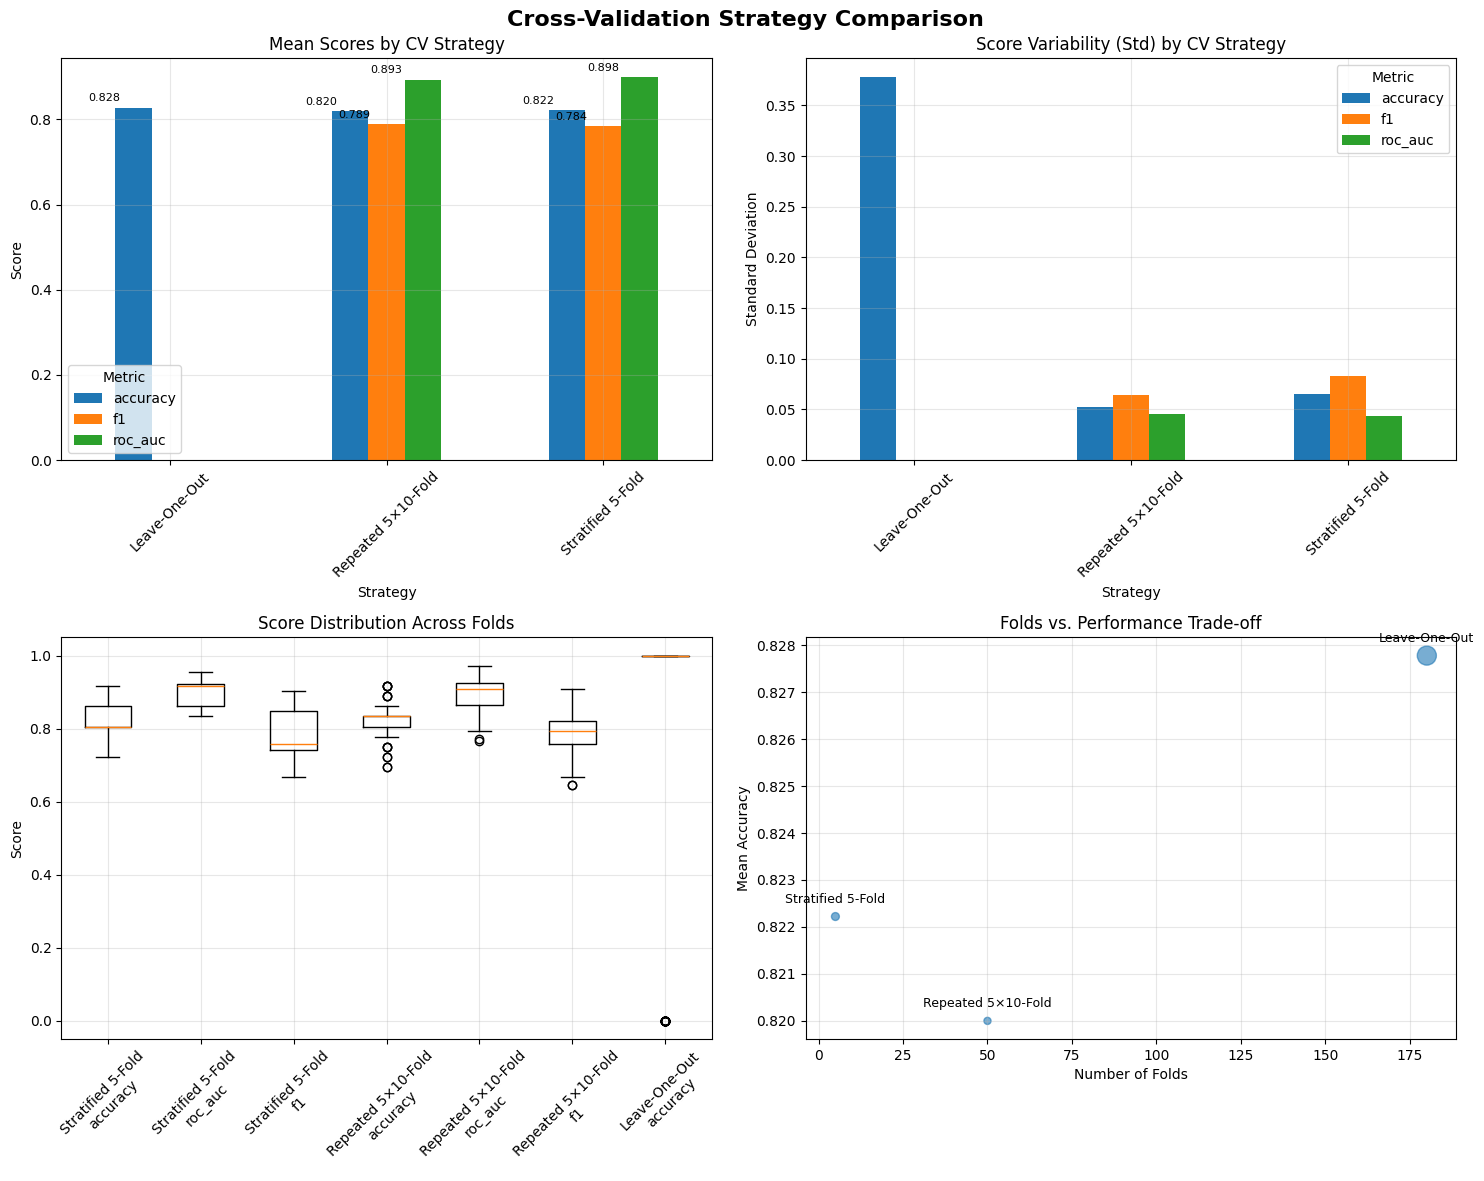


5. SAVING CV SPLITS FOR REPRODUCIBILITY
Saved stratified_kfold splits to ../Data/cv_splits\stratified_kfold_splits.pkl
Saved repeated_stratified_kfold splits to ../Data/cv_splits\repeated_stratified_kfold_splits.pkl
Saved leave_one_out splits to ../Data/cv_splits\leave_one_out_splits.pkl
Saved results summary to ../Data/cv_splits\cv_results_summary.pkl

CROSS-VALIDATION RECOMMENDATIONS

📋 RECOMMENDED CV STRATEGIES:

1. FOR MODEL SELECTION & HYPERPARAMETER TUNING:
   - Stratified 5-Fold or 10-Fold CV
   - Repeated Stratified K-Fold (more robust estimates)

2. FOR FINAL MODEL EVALUATION:
   - Use held-out test set (never seen during CV)
   - Report both CV performance and test set performance

3. FOR SMALL DATASETS (<100 samples):
   - Consider Leave-One-Out CV for maximum data usage
   - Warning: Computationally expensive, high variance

4. FOR CLASS IMBALANCE:
   - Always use STRATIFIED versions
   - Monitor class distribution in each fold

5. FOR REPRODUCIBILITY:
   - Set random_stat

In [ ]:
# ============================================================================
# COMPREHENSIVE CROSS-VALIDATION FRAMEWORK CLASS
# ============================================================================

class CrossValidationFramework:
    """
    A comprehensive cross-validation framework for model evaluation.
    Supports multiple CV strategies with detailed statistics and visualization.
    """
    
    def __init__(self, X, y, feature_names=None, target_name='target'):
        # Initialize the CV framework.
        self.X = X
        self.y = y
        self.feature_names = feature_names if feature_names else X.columns.tolist()
        self.target_name = target_name
        self.results = {}
        self.splits = {}
        
        print(f"   CrossValidationFramework initialized")
        print(f"   Samples: {len(X)}, Features: {X.shape[1]}")
        print(f"   Target distribution: {pd.Series(y).value_counts().to_dict()}")
    
    def stratified_kfold_cv(self, model, n_splits=5, shuffle=True, random_state=42, 
                           scoring=None, return_train_score=False):
        # Perform Stratified K-Fold Cross-Validation.
        print(f"\nPerforming Stratified {n_splits}-Fold Cross-Validation...")
        
        if scoring is None:
            scoring = ['accuracy', 'roc_auc', 'f1', 'precision', 'recall']
        elif isinstance(scoring, str):
            scoring = [scoring]
        
        # Create StratifiedKFold
        skf = StratifiedKFold(
            n_splits=n_splits,
            shuffle=shuffle,
            random_state=random_state
        )
        
        # Store split indices for reproducibility
        split_indices = list(skf.split(self.X, self.y))
        self.splits['stratified_kfold'] = split_indices
        
        # Perform cross-validation with multiple metrics
        cv_results = cross_validate(
            model, self.X, self.y,
            cv=skf,
            scoring=scoring,
            return_train_score=return_train_score,
            return_estimator=True,
            n_jobs=-1
        )
        
        # Calculate detailed statistics
        results_summary = self._calculate_statistics(cv_results, scoring)
        
        # Store results
        self.results['stratified_kfold'] = {
            'cv_results': cv_results,
            'summary': results_summary,
            'parameters': {
                'n_splits': n_splits,
                'shuffle': shuffle,
                'random_state': random_state
            }
        }
        
        # Print results
        self._print_cv_results(results_summary, 'Stratified K-Fold')
        
        return cv_results, results_summary
    
    def repeated_stratified_kfold_cv(self, model, n_splits=5, n_repeats=10, random_state=42,
                                    scoring=None):
        # Perform Repeated Stratified K-Fold Cross-Validation.

        print(f"\nPerforming Repeated Stratified K-Fold CV ({n_repeats} repeats × {n_splits} folds)...")
        
        if scoring is None:
            scoring = ['accuracy', 'roc_auc', 'f1']
        elif isinstance(scoring, str):
            scoring = [scoring]
        
        # Create RepeatedStratifiedKFold
        rskf = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=random_state
        )
        
        # Store split indices
        split_indices = list(rskf.split(self.X, self.y))
        self.splits['repeated_stratified_kfold'] = split_indices
        
        # Perform cross-validation
        cv_results = cross_validate(
            model, self.X, self.y,
            cv=rskf,
            scoring=scoring,
            return_estimator=False,
            n_jobs=-1
        )
        
        # Calculate detailed statistics
        results_summary = self._calculate_statistics(cv_results, scoring)
        
        # Store results
        self.results['repeated_stratified_kfold'] = {
            'cv_results': cv_results,
            'summary': results_summary,
            'parameters': {
                'n_splits': n_splits,
                'n_repeats': n_repeats,
                'random_state': random_state
            }
        }
        
        # Print results
        self._print_cv_results(results_summary, 'Repeated Stratified K-Fold')
        
        # Print repeat-wise statistics
        self._print_repeat_statistics(cv_results, scoring, n_splits, n_repeats)
        
        return cv_results, results_summary
    
    def leave_one_out_cv(self, model, scoring=None):
        # Perform Leave-One-Out Cross-Validation.
        print(f"\nPerforming Leave-One-Out Cross-Validation ({len(self.X)} folds)...")
        
        if scoring is None:
            scoring = ['accuracy']  # LOOCV is computationally expensive
        elif isinstance(scoring, str):
            scoring = [scoring]
        
        # Check if dataset is too large for LOOCV
        if len(self.X) > 1000:
            print("   Warning: Dataset has >1000 samples. LOOCV may be computationally expensive.")
            print("   Consider using stratified k-fold instead.")
        
        # Create LeaveOneOut
        loo = LeaveOneOut()
        
        # Store split indices
        split_indices = list(loo.split(self.X, self.y))
        self.splits['leave_one_out'] = split_indices
        
        # For large datasets, limit to accuracy only
        if len(self.X) > 500 and scoring != ['accuracy']:
            print("   Using only accuracy metric for computational efficiency...")
            scoring = ['accuracy']
        
        # Perform cross-validation
        cv_results = cross_validate(
            model, self.X, self.y,
            cv=loo,
            scoring=scoring,
            return_estimator=False,
            n_jobs=-1
        )
        
        # Calculate detailed statistics
        results_summary = self._calculate_statistics(cv_results, scoring)
        
        # Store results
        self.results['leave_one_out'] = {
            'cv_results': cv_results,
            'summary': results_summary,
            'parameters': {}
        }
        
        # Print results
        self._print_cv_results(results_summary, 'Leave-One-Out')
        
        return cv_results, results_summary
    
    def _calculate_statistics(self, cv_results, scoring):
        """Calculate detailed statistics from CV results."""
        results_summary = {}
        
        # Handle both list and single string scoring
        if isinstance(scoring, str):
            scoring = [scoring]
        
        for metric in scoring:
            test_key = f'test_{metric}'
            if test_key in cv_results:
                scores = cv_results[test_key]
                results_summary[metric] = {
                    'mean': np.mean(scores),
                    'std': np.std(scores),
                    'min': np.min(scores),
                    'max': np.max(scores),
                    'median': np.median(scores),
                    'iqr': np.percentile(scores, 75) - np.percentile(scores, 25),
                    'scores': scores.tolist()
                }
        
        return results_summary
    
    def _print_cv_results(self, results_summary, cv_name):
        """Print CV results in a formatted way."""
        print(f"\n{cv_name} Results:")
        print("-" * 60)
        
        for metric, stats in results_summary.items():
            print(f"  {metric.upper():<12}: {stats['mean']:.4f} (±{stats['std']:.4f}) "
                  f"[{stats['min']:.4f}-{stats['max']:.4f}]")
    
    def _print_repeat_statistics(self, cv_results, scoring, n_splits, n_repeats):
        """Print statistics for repeated CV."""
        print(f"\nRepeat-Wise Statistics:")
        print("-" * 60)
        
        # Handle both list and single string scoring
        if isinstance(scoring, str):
            scoring = [scoring]
        
        for metric in scoring:
            test_key = f'test_{metric}'
            if test_key in cv_results:
                scores = cv_results[test_key]
                
                # Reshape scores into repeats
                scores_by_repeat = scores.reshape(n_repeats, n_splits)
                
                # Calculate statistics per repeat
                repeat_means = scores_by_repeat.mean(axis=1)
                repeat_stds = scores_by_repeat.std(axis=1)
                
                print(f"\n  {metric.upper()}:")
                print(f"    Mean across repeats: {repeat_means.mean():.4f} (±{repeat_means.std():.4f})")
                print(f"    Best repeat: {repeat_means.max():.4f}")
                print(f"    Worst repeat: {repeat_means.min():.4f}")
                print(f"    Repeat variability: {repeat_stds.mean():.4f}")
    
    def compare_cv_strategies(self, model, cv_configs=None):
        # Compare different cross-validation strategies.
        print("\n" + "=" * 80)
        print("COMPARING CROSS-VALIDATION STRATEGIES")
        print("=" * 80)
        
        if cv_configs is None:
            cv_configs = [
                {'name': 'Stratified 5-Fold', 'method': 'stratified_kfold', 
                 'params': {'n_splits': 5, 'scoring': ['accuracy', 'roc_auc', 'f1']}},
                {'name': 'Repeated 5×10-Fold', 'method': 'repeated_stratified_kfold',
                 'params': {'n_splits': 5, 'n_repeats': 10, 'scoring': ['accuracy', 'roc_auc', 'f1']}},
                {'name': 'Leave-One-Out', 'method': 'leave_one_out',
                 'params': {'scoring': ['accuracy']}}
            ]
        
        comparison_results = []
        
        for config in cv_configs:
            print(f"\nEvaluating: {config['name']}")
            print("-" * 40)
            
            try:
                # Call appropriate CV method
                if config['method'] == 'stratified_kfold':
                    cv_results, summary = self.stratified_kfold_cv(model, **config['params'])
                elif config['method'] == 'repeated_stratified_kfold':
                    cv_results, summary = self.repeated_stratified_kfold_cv(model, **config['params'])
                elif config['method'] == 'leave_one_out':
                    cv_results, summary = self.leave_one_out_cv(model, **config['params'])
                else:
                    continue
                
                # Extract results for comparison
                for metric, stats in summary.items():
                    comparison_results.append({
                        'Strategy': config['name'],
                        'Metric': metric,
                        'Mean': stats['mean'],
                        'Std': stats['std'],
                        'Min': stats['min'],
                        'Max': stats['max'],
                        'Num_Folds': len(stats['scores'])
                    })
                    
            except Exception as e:
                print(f"Error with {config['name']}: {e}")
                comparison_results.append({
                    'Strategy': config['name'],
                    'Metric': 'error',
                    'Mean': np.nan,
                    'Std': np.nan,
                    'Min': np.nan,
                    'Max': np.nan,
                    'Num_Folds': 0
                })
        
        # Create comparison DataFrame
        comparison_df = pd.DataFrame(comparison_results)
        
        # Display results
        print("\n" + "=" * 80)
        print("COMPARISON SUMMARY")
        print("=" * 80)
        
        # Pivot table for better visualization
        pivot_mean = comparison_df.pivot_table(
            index='Strategy', columns='Metric', values='Mean'
        )
        
        pivot_std = comparison_df.pivot_table(
            index='Strategy', columns='Metric', values='Std'
        )
        
        print("\nMean Scores:")
        print(pivot_mean.round(4).to_string())
        
        print("\nStandard Deviations:")
        print(pivot_std.round(4).to_string())
        
        # Visualize comparison
        self._visualize_comparison(comparison_df)
        
        return comparison_df
    
    def _visualize_comparison(self, comparison_df):
        """Visualize CV strategy comparison."""
        # Filter out error rows
        plot_df = comparison_df[comparison_df['Metric'] != 'error'].copy()
        
        if len(plot_df) == 0:
            print("No valid results to visualize")
            return
        
        # Create figure
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Cross-Validation Strategy Comparison', fontsize=16, fontweight='bold')
        
        # Plot 1: Mean scores by strategy
        ax1 = axes[0, 0]
        pivot_mean = plot_df.pivot(index='Strategy', columns='Metric', values='Mean')
        pivot_mean.plot(kind='bar', ax=ax1, rot=45)
        ax1.set_title('Mean Scores by CV Strategy')
        ax1.set_ylabel('Score')
        ax1.legend(title='Metric')
        ax1.grid(True, alpha=0.3)
        
        # Add value labels
        for i, (idx, row) in enumerate(pivot_mean.iterrows()):
            for j, (metric, value) in enumerate(row.items()):
                ax1.text(i - 0.3 + j*0.15, value + 0.01, f'{value:.3f}', 
                        ha='center', va='bottom', fontsize=8)
        
        # Plot 2: Score variability (std) by strategy
        ax2 = axes[0, 1]
        pivot_std = plot_df.pivot(index='Strategy', columns='Metric', values='Std')
        pivot_std.plot(kind='bar', ax=ax2, rot=45)
        ax2.set_title('Score Variability (Std) by CV Strategy')
        ax2.set_ylabel('Standard Deviation')
        ax2.legend(title='Metric')
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Score distribution across folds
        ax3 = axes[1, 0]
        
        # Prepare data for box plot
        box_data = []
        box_labels = []
        
        for strategy in plot_df['Strategy'].unique():
            strategy_data = plot_df[plot_df['Strategy'] == strategy]
            for metric in ['accuracy', 'roc_auc', 'f1']:
                if metric in strategy_data['Metric'].values:
                    metric_data = strategy_data[strategy_data['Metric'] == metric]
                    # Get scores from stored results
                    for _, row in metric_data.iterrows():
                        strategy_name = row['Strategy']
                        metric_name = row['Metric']
                        result_key = None
                        
                        # Find the corresponding result key
                        if 'Stratified 5-Fold' in strategy_name:
                            result_key = 'stratified_kfold'
                        elif 'Repeated' in strategy_name:
                            result_key = 'repeated_stratified_kfold'
                        elif 'Leave-One-Out' in strategy_name:
                            result_key = 'leave_one_out'
                        
                        if result_key and result_key in self.results:
                            if metric_name in self.results[result_key]['summary']:
                                scores = self.results[result_key]['summary'][metric_name]['scores']
                                box_data.append(scores)
                                box_labels.append(f"{strategy_name}\n{metric_name}")
        
        if box_data:
            ax3.boxplot(box_data, labels=box_labels, vert=True)
            ax3.set_title('Score Distribution Across Folds')
            ax3.set_ylabel('Score')
            ax3.tick_params(axis='x', rotation=45)
            ax3.grid(True, alpha=0.3)
        
        # Plot 4: Number of folds vs. performance
        ax4 = axes[1, 1]
        
        scatter_data = plot_df[plot_df['Metric'] == 'accuracy']
        if len(scatter_data) > 0:
            ax4.scatter(scatter_data['Num_Folds'], scatter_data['Mean'], 
                       s=scatter_data['Std']*500, alpha=0.6)
            
            for _, row in scatter_data.iterrows():
                ax4.annotate(row['Strategy'], 
                           (row['Num_Folds'], row['Mean']),
                           textcoords="offset points",
                           xytext=(0,10),
                           ha='center',
                           fontsize=9)
            
            ax4.set_xlabel('Number of Folds')
            ax4.set_ylabel('Mean Accuracy')
            ax4.set_title('Folds vs. Performance Trade-off')
            ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def save_splits(self, output_dir='../Data/cv_splits'):
        """Save CV splits to disk for reproducibility."""
        os.makedirs(output_dir, exist_ok=True)
        
        for split_name, split_indices in self.splits.items():
            filename = os.path.join(output_dir, f'{split_name}_splits.pkl')
            with open(filename, 'wb') as f:
                pickle.dump(split_indices, f)
            print(f"Saved {split_name} splits to {filename}")
        
        # Also save results summary
        results_file = os.path.join(output_dir, 'cv_results_summary.pkl')
        with open(results_file, 'wb') as f:
            pickle.dump(self.results, f)
        print(f"Saved results summary to {results_file}")
    
    def print_recommendations(self):
        """Print CV strategy recommendations."""
        print("\n" + "=" * 80)
        print("CROSS-VALIDATION RECOMMENDATIONS")
        print("=" * 80)
        
        print("""
RECOMMENDED CV STRATEGIES:

1. FOR MODEL SELECTION & HYPERPARAMETER TUNING:
   - Stratified 5-Fold or 10-Fold CV
   - Repeated Stratified K-Fold (more robust estimates)

2. FOR FINAL MODEL EVALUATION:
   - Use held-out test set (never seen during CV)
   - Report both CV performance and test set performance

3. FOR SMALL DATASETS (<100 samples):
   - Consider Leave-One-Out CV for maximum data usage
   - Warning: Computationally expensive, high variance

4. FOR CLASS IMBALANCE:
   - Always use STRATIFIED versions
   - Monitor class distribution in each fold

5. FOR REPRODUCIBILITY:
   - Set random_state parameter
   -  Save CV splits to disk
   -  Report mean ± std for all metrics

BEST PRACTICES:
- Use multiple metrics (accuracy, ROC-AUC, F1)
- Check for overfitting (train vs test performance)
- Use confidence intervals when reporting results
- Document all CV parameters for reproducibility
""")

# ============================================================================
# DEMONSTRATION
# ============================================================================

# Initialize model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("=" * 80)
print("HEART DISEASE PREDICTION - CROSS-VALIDATION FRAMEWORK")
print("=" * 80)

# Initialize CV framework
cv_framework = CrossValidationFramework(X, y, target_name='heart_disease_present')

# 1. Stratified K-Fold CV
print("\n" + "=" * 80)
print("1. STRATIFIED 5-FOLD CROSS-VALIDATION")
print("=" * 80)

cv_framework.stratified_kfold_cv(
    model=model,
    n_splits=5,
    shuffle=True,
    random_state=42,
    scoring=['accuracy', 'roc_auc', 'f1', 'precision', 'recall']
)

# 2. Repeated Stratified K-Fold CV
print("\n" + "=" * 80)
print("2. REPEATED STRATIFIED K-FOLD CROSS-VALIDATION")
print("=" * 80)

cv_framework.repeated_stratified_kfold_cv(
    model=model,
    n_splits=5,
    n_repeats=3,  # Using 3 repeats for demo (10 would take longer)
    random_state=42,
    scoring=['accuracy', 'roc_auc', 'f1']
)

# 3. Leave-One-Out CV (for demonstration)
print("\n" + "=" * 80)
print("3. LEAVE-ONE-OUT CROSS-VALIDATION")
print("=" * 80)

if len(X) <= 500:  # Only run LOOCV for reasonable dataset sizes
    cv_framework.leave_one_out_cv(
        model=model,
        scoring=['accuracy']
    )
else:
    print(f"  Dataset too large for LOOCV ({len(X)} samples)")
    print("   Skipping LOOCV due to computational constraints")

# 4. Compare CV strategies
print("\n" + "=" * 80)
print("4. COMPARING ALL CV STRATEGIES")
print("=" * 80)

comparison_df = cv_framework.compare_cv_strategies(model)

# 5. Save splits for reproducibility
print("\n" + "=" * 80)
print("5. SAVING CV SPLITS FOR REPRODUCIBILITY")
print("=" * 80)

cv_framework.save_splits()

# 6. Print recommendations
cv_framework.print_recommendations()

# 7. Create summary report
print("\n" + "=" * 80)
print("SUMMARY REPORT")
print("=" * 80)

print(f"Dataset: {len(X)} samples, {X.shape[1]} features")
print(f"Target: {cv_framework.target_name}")
print(f"Class distribution: {pd.Series(y).value_counts().to_dict()}")
print(f"CV strategies evaluated: {len(cv_framework.results)}")

# Best performing strategy
if 'stratified_kfold' in cv_framework.results:
    best_acc = cv_framework.results['stratified_kfold']['summary']['accuracy']['mean']
    print(f"\nBest accuracy (Stratified 5-Fold): {best_acc:.4f}")

if 'repeated_stratified_kfold' in cv_framework.results:
    best_acc_repeated = cv_framework.results['repeated_stratified_kfold']['summary']['accuracy']['mean']
    print(f"Best accuracy (Repeated): {best_acc_repeated:.4f}")

print("\nCross-validation framework execution complete!")